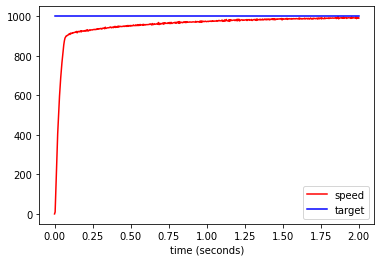

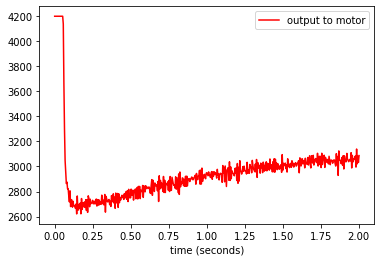

In [9]:
import sys
sys.path.append("../../")

import time
import math

from lib.data.dataplot import *
from lib.utils.time import *
from lib.system.basic import *
from lib.hardware.motor_driver import *

class SimpleSpeedControl:
    
    def __init__(self, _kp, _ki):
        self.P = Proportional(_kp)
        self.I = Integrator()
        self.ki = _ki
        
    def evaluate(self, delta_t, error):
        return self.P.evaluate(delta_t, error) + self.ki * self.I.evaluate(delta_t, error)


dvel = DataPlotter()
dvel.set_x("time (seconds)")
dvel.add_y("speed", "speed")
dvel.add_y("target", "target")

c_out = DataPlotter()
c_out.set_x("time (seconds)")
c_out.add_y("output", "output to motor")

m = MotorDriver()
m.open()

d = Derivator()

target_speed = 1000.0
ctrl = SimpleSpeedControl(19.0, 32.0)

tm = Time()
tm.start()
while tm.get() < 2:

    delta_t = tm.elapsed()
    
    position = m.encoder()
    speed = d.evaluate(delta_t, position)
    
    position = position * 360/84000
    speed = speed * 360/84000
    
    error = target_speed - speed
    output = ctrl.evaluate(delta_t, error)
    
    if output > 4200:
        output = 4200
    elif output < -4200:
        output = -4200
        
    c_out.append_x(tm.get())
    c_out.append_y("output", output)
    
    m.pwm(output) # range [-4200, 4200]

    dvel.append_x(tm.get())
    dvel.append_y("speed", speed)
    dvel.append_y("target", target_speed)
    
m.pwm(0)
dvel.plot()
c_out.plot()

